In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

## RHS

In [2]:
def L96_RK4_quenched(x0, F0=16.0, F_sigma=2.0, s=0.0, dt=0.001, N=10000, rand_seed=123):
    """
    Lorenz-96 with RK4 for deterministic part and Euler-Maruyama for additive noise.
    Includes Spatially Dependent Quenched Disorder (Random Topography F_i) AND 
    Energy-Conserving Structural Asymmetry (Interaction strengths C_i).

    Note: we can use RK4 for this SDE because the noise is additive. We cannot do the same
    for multiplicative noise. In that case go e.g. Milstein method
    
    Equation:
    dx_i/dt = x_{i-1} * (x_{i+1} - x_{i-2}) - x_i + F_i + s*dW_i
    
    Where F_i = F0 + xi_i, with xi_i ~ N(0, F_sigma^2) clipped at 4.0.
    """
    rng = np.random.default_rng(rand_seed)
    K = len(x0)
    x = np.zeros((N+1, K))
    x[0] = x0

    # 1. Generate Quenched Disorder (The External "Topography" F_vec)
    if F_sigma > 0:
        perturbation = rng.normal(0, F_sigma, K)
        F_vec = F0 + perturbation
        # We ensure F_i is at least 4 to maintain chaotic forcing
        F_vec = np.maximum(F_vec, 4.0)
    else:
        F_vec = np.full(K, F0)

    # 3. Generate Time-Dependent Noise (The "Weather")
    dW = rng.normal(0, 1, (N, K)) * np.sqrt(dt)

    # Deterministic drift with Vectorized F_vec and asymmetric C_vec
    def f_det(x_curr):
        # Energy-conserving triad interactions:
        # np.roll(x, -1) -> x_{i+1}
        # np.roll(x, 2)  -> x_{i-2}
        # np.roll(x, 1)  -> x_{i-1}
        adv_term = np.roll(x_curr, 1) * (np.roll(x_curr, -1) - np.roll(x_curr, 2))
        return adv_term - x_curr + F_vec

    for t in range(N):
        # RK4 steps for the deterministic part
        k1 = f_det(x[t])
        k2 = f_det(x[t] + 0.5 * dt * k1)
        k3 = f_det(x[t] + 0.5 * dt * k2)
        k4 = f_det(x[t] + dt * k3)
        
        dx_det = (k1 + 2*k2 + 2*k3 + k4) / 6.0

        # Update: Deterministic RK4 increment + Stochastic Euler increment
        x[t+1] = x[t] + dx_det * dt + s * dW[t]

    return x, F_vec

## Model 1 trajectory

In [3]:
# Parameters MODEL

Nk = 20
F = 16.0
s = 5 # small noise
F_sigma = 10
# Note: there is a clipping procedure such that F is at least 4

# Parameters simulation

transient = 1000
T = 50000000 + transient     # 10000000
dt = 0.01
#t_eval = np.arange(0, T * dt, dt)
# Initial condition
x0 = np.random.randn(Nk)

In [18]:
%%time
L_96_numerical = L96_RK4_quenched(x0, F0=F, F_sigma=F_sigma, s=s, dt=dt, N=T, rand_seed=123)
orbit_rk4 = L_96_numerical[0][transient:]
F_j = L_96_numerical[1]

CPU times: user 51min 27s, sys: 9.81 s, total: 51min 37s
Wall time: 51min 47s


In [20]:
np.save('./results/L96_orbit.npy',orbit_rk4)

In [21]:
np.save('./results/F_j.npy',F_j)

## Mean and variance of the invariant distribution

In [33]:
trajectory = np.load('./results/L96_orbit.npy')
mean = np.mean(trajectory,0)
sigmas = np.std(trajectory,0)
np.save('./results/mean_invariant_density.npy',mean)
np.save('./results/sigma_invariant_density.npy',sigmas)

In [34]:
F_j = np.load('./results/F_j.npy')
mean = np.load('./results/mean_invariant_density.npy')

In [35]:
F_j

array([ 6.1087865 , 12.32213349, 28.87925261, 17.93974419, 25.202309  ,
       21.77103791,  9.63536354, 21.4195222 , 12.83404549, 12.77610884,
       16.97167319,  4.        , 27.92166104,  9.28910325, 26.0026942 ,
       17.36321124, 31.3203308 ,  9.40030586, 12.88205144, 19.37769127])

In [36]:
mean

array([1.69736309, 2.04434646, 4.43155587, 3.30610858, 2.81256496,
       3.21354122, 1.925385  , 2.98524438, 2.67287567, 2.11949188,
       2.79391745, 1.64175222, 3.82452752, 2.56275376, 3.33148282,
       3.06316329, 3.73381947, 1.6040563 , 1.80722273, 3.26444563])

In [44]:
trajectory.T

array([[-7.86447153e+00, -3.36564820e+00, -7.08550448e-03, ...,
        -3.19334754e+00, -3.25747225e+00, -2.97598129e+00],
       [-1.96110697e+01, -2.04793387e+01, -2.04385741e+01, ...,
        -3.83481188e+00, -3.48311598e+00, -3.41964846e+00],
       [ 5.34531728e+00,  4.18715896e+00,  4.60336665e+00, ...,
         3.31413424e-01,  1.86202559e+00,  1.78996118e+00],
       ...,
       [-4.13945245e+00, -4.40648969e+00, -4.44689762e+00, ...,
        -2.28848289e+00, -1.94969462e+00, -2.24929733e+00],
       [ 2.59515681e+00,  2.95914366e+00,  3.09069376e+00, ...,
         7.69428424e+00,  8.08836017e+00,  8.34476219e+00],
       [-1.43574921e+01, -1.44186904e+01, -1.39395678e+01, ...,
         1.96464813e+00,  1.99967229e+00,  2.15138700e+00]],
      shape=(20, 50000001))

Text(0.5, 1.0, '$u_i(t)$')

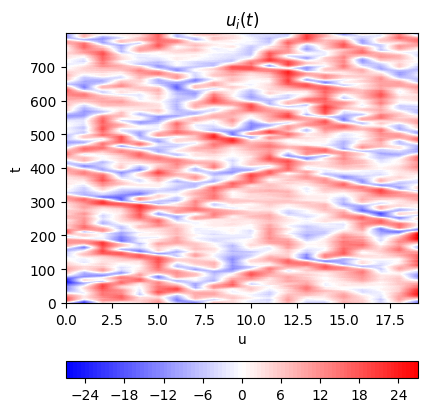

In [40]:
from matplotlib import colormaps

fig = plt.figure(figsize=(10, 5))

ax = fig.add_subplot(1,2,1)
plt.contourf(trajectory[:800],levels=100, cmap='bwr')
plt.colorbar(orientation="horizontal")
plt.xlabel("u")
plt.ylabel("t")
plt.title("$u_i(t)$")